# Score-Based Causal Discovery with `causal-learn` & NOTEARS — Adult Income Dataset

This notebook is a companion to `constraint_based_algorithms.ipynb`. It covers three complementary paradigms for causal structure learning — all starting from observational data.

| Section | Algorithm | Paradigm | Score / Loss | Output |
|---------|-----------|----------|--------------|--------|
| 3a | **GES** | Score-based greedy | BIC (Gaussian) | CPDAG |
| 3b | **GES** | Score-based greedy | BDeu (discrete) | CPDAG |
| 3c | **GES** | Score-based greedy | CV kernel (mixed) | CPDAG |
| 4 | **NOTEARS** | Continuous optimisation | L2 + L1 + acyclicity | DAG |
| 5 | **GRaSP** | Permutation-based | BIC | CPDAG |
| 6a | **GES + prior** | Custom score | BDeu + immutability penalty | CPDAG |
| 6b | **LLM penalty matrix** | LLM setup | Per-direction plausibility 0–10 | (used by 6c, 6d) |
| 6c | **GRaSP + LLM** | Permutation-based | BIC + LLM penalty | CPDAG |
| 6d | **NOTEARS + LLM** | Continuous optim. | L2 + per-edge weighted L1 | DAG |

**The Adult dataset** (32 561 rows × 15 columns) contains demographic and employment data.  
The target variable `income` encodes whether a person earns >50K/year.

> **Score cheat-sheet**  
> `BIC` (Bayesian Information Criterion) → penalised log-likelihood for linear Gaussian data  
> `BDeu` (Bayesian Dirichlet equivalent uniform) → marginal likelihood for discrete data  
> `CV kernel` → nonparametric RKHS regression, k-fold cross-validated likelihood (handles mixed data)  
> All three balance model fit against complexity. Larger penalty → sparser graph.

In [1]:
cd ..

/Users/linafaik/Documents/projects/causal-models-ai


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PATH"] += ":/opt/homebrew/bin"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from sklearn.preprocessing import LabelEncoder
from IPython.display import Image, display

# Score-based
from causallearn.search.ScoreBased.GES import ges

# Continuous optimisation
from notears.linear import notears_linear

# Permutation-based
from causallearn.search.PermutationBased.GRaSP import grasp

# Score functions (used directly in custom-score sections)
from causallearn.score.LocalScoreFunction import local_score_BIC, local_score_BDeu

# Graph utilities
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.graph.GraphNode import GraphNode

## 1. Load & Explore the Data

In [3]:
df = pd.read_csv("data/adult.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nMissing values (encoded as '?'):")
print((df == "?").mean().loc[lambda s: s > 0].round(3))
df.head(3)

Shape: (32561, 15)

Column types:
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

Missing values (encoded as '?'):
workclass         0.056
occupation        0.057
native.country    0.018
dtype: float64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K


## 2. Preprocessing

`causal-learn` expects a **NumPy array of floats** — no NaNs, no strings.  
We build two subsets depending on the algorithm:

- **Continuous** (for BIC / NOTEARS / GRaSP): 5 numeric columns, no missing values
- **Discrete** (for BDeu): rows with `?` dropped, then
  - `age`, `education.num`, `hours.per.week`, `income` → binned into named categories
  - all 8 columns label-encoded (one integer column per variable)

In [4]:
# ── 2a. Continuous variables ──────────────────────────────────────────────────
# fnlwgt is a survey sampling weight — not a causal variable; excluded.
CONT_COLS = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

df_cont    = df[CONT_COLS].copy()
data_cont  = df_cont.values.astype(float)
node_names_cont = list(df_cont.columns)

print(f"Continuous subset: {data_cont.shape}")
df_cont.describe().round(1)

Continuous subset: (32561, 5)


,age,education.num,capital.gain,capital.loss,hours.per.week
count,32561.0,32561.0,32561.0,32561.0,32561.0
mean,38.6,10.1,1077.6,87.3,40.4
std,13.6,2.6,7385.3,403.0,12.3
min,17.0,1.0,0.0,0.0,1.0
25%,28.0,9.0,0.0,0.0,40.0
50%,37.0,10.0,0.0,0.0,40.0
75%,48.0,12.0,0.0,0.0,45.0
max,90.0,16.0,99999.0,4356.0,99.0


In [5]:
# ── 2b. Discrete variables ────────────────────────────────────────────────────
# - Continuous-but-coarse columns are binned into named buckets.
# - All resulting categoricals are label-encoded for BDeu.
RAW_COLS = ["age", "education.num", "hours.per.week",
            "marital.status", "occupation", "relationship", "sex", "income"]

df_raw = df[RAW_COLS].replace("?", np.nan).dropna().copy()

# Named bins for the originally-numeric columns (edges informed by distributions above)
df_raw["age_group"] = pd.cut(
    df_raw["age"],
    bins=[16, 25, 35, 45, 55, 91],
    labels=["young", "early_career", "mid_career", "late_career", "senior"],
)
df_raw["edu_group"] = pd.cut(
    df_raw["education.num"],
    bins=[0, 8, 9, 12, 13, 16],
    labels=["below_hs", "hs_grad", "some_college", "bachelors", "graduate"],
)
df_raw["hours_group"] = pd.cut(
    df_raw["hours.per.week"],
    bins=[0, 34, 40, 50, 99],
    labels=["part_time", "standard", "overtime", "heavy"],
)
df_raw["income_group"] = df_raw["income"].map({"<=50K": "low", ">50K": "high"})

# Label-encode everything we're keeping (one integer column per variable)
KEEP_COLS = ["age_group", "edu_group", "hours_group", "income_group",
             "marital.status", "occupation", "relationship", "sex"]

df_disc = pd.DataFrame(index=df_raw.index)
for col in KEEP_COLS:
    df_disc[col] = LabelEncoder().fit_transform(df_raw[col].astype(str))

data_disc       = df_disc.values.astype(int)
node_names_disc = list(df_disc.columns)

print(f"Discrete subset: {data_disc.shape}")
print(f"Node names ({len(node_names_disc)}):")
for n in node_names_disc:
    print(f"  - {n}")
df_disc.head(3)

Discrete subset: (30718, 8)
Node names (8):
  - age_group
  - edu_group
  - hours_group
  - income_group
  - marital.status
  - occupation
  - relationship
  - sex


,age_group,edu_group,hours_group,income_group,marital.status,occupation,relationship,sex
1,3,3,2,1,6,3,1,0
3,1,1,3,1,0,6,4,0
4,2,4,3,1,5,9,3,0


## 3. Score-Based: GES (Greedy Equivalence Search)

GES searches for the **CPDAG** (equivalence class of DAGs) that maximises a score criterion.  
It runs in two phases:

1. **Forward phase** — greedily add the edge that most improves the score
2. **Backward phase** — greedily remove edges that further improve the score

Because each phase starts from the previous result, GES is guaranteed to reach a local optimum in polynomial time.  
Unlike PC, GES never runs conditional independence tests — it scores whole graphs.

**Key parameter: `lambda_value`** (penalty weight in BIC)
```
score(i, Pa_i) = –n/2 · (1 + log σ̂²) – λ · (|Pa_i| + 1) · log n
```
- Default λ = 0.5  (standard BIC)
- Larger λ → stronger sparsity pressure → fewer edges
- Smaller λ → denser graph (more edges)

### 3a. Continuous Data — BIC Score

In [6]:
record_bic = ges(
    data_cont,
    score_func="local_score_BIC",
    node_names=node_names_cont,
)

G_bic = record_bic["G"]

# Adjacency matrix
adj_bic = pd.DataFrame(
    G_bic.graph, index=node_names_cont, columns=node_names_cont
)
print("Adjacency matrix (GES – BIC):")
print(adj_bic)

print("\nEdge list (CPDAG):")
for edge in G_bic.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_bic.get_graph_edges())}  |  BIC score: {record_bic['score']:.1f}")

Adjacency matrix (GES – BIC):
                age  education.num  capital.gain  capital.loss  hours.per.week
age               0              0            -1            -1              -1
education.num     0              0            -1            -1              -1
capital.gain     -1             -1             0            -1              -1
capital.loss     -1             -1            -1             0              -1
hours.per.week   -1             -1            -1            -1               0

Edge list (CPDAG):
  age --- capital.gain
  age --- capital.loss
  age --- hours.per.week
  education.num --- capital.gain
  education.num --- capital.loss
  education.num --- hours.per.week
  capital.gain --- capital.loss
  capital.gain --- hours.per.week
  capital.loss --- hours.per.week

Total edges: 9  |  BIC score: -763469.5


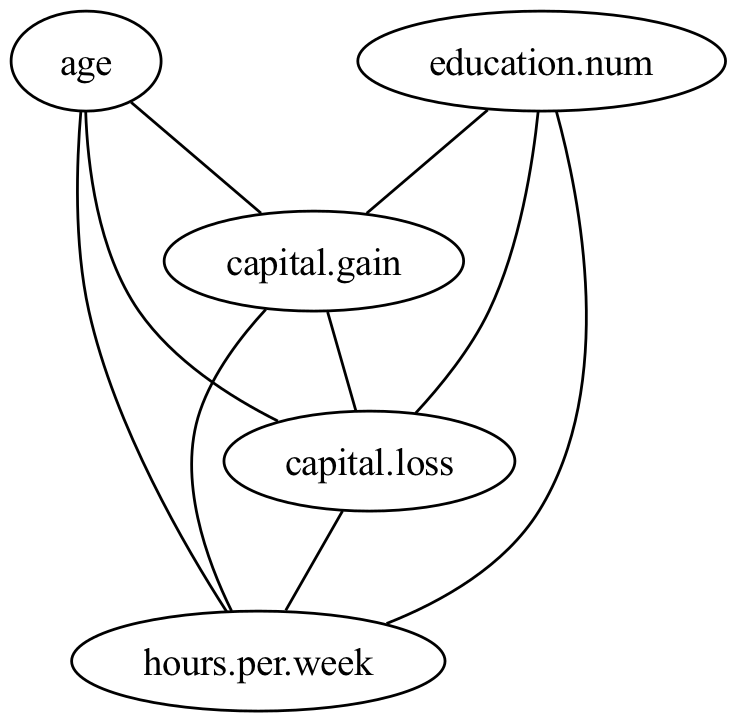

In [7]:
pyd = GraphUtils.to_pydot(G_bic, labels=node_names_cont)
display(Image(pyd.create_png()))

### 3b. Discrete Data — BDeu Score

For categorical variables we use the **BDeu score** (Bayesian Dirichlet equivalent uniform).  
It computes the marginal likelihood under a Dirichlet prior, assuming discrete variables with known cardinalities.  
No Gaussianity assumption required — each variable can have any number of levels.

In [8]:
record_bdeu = ges(
    data_disc,
    score_func="local_score_BDeu",
    node_names=node_names_disc,
)

G_bdeu = record_bdeu["G"]

print("Edge list (GES – BDeu, CPDAG):")
for edge in G_bdeu.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_bdeu.get_graph_edges())}  |  BDeu score: {record_bdeu['score']:.1f}")

Edge list (GES – BDeu, CPDAG):
  age_group --- hours_group
  age_group --- income_group
  age_group --- marital.status
  age_group --- relationship
  income_group --> edu_group
  occupation --> edu_group
  hours_group --- income_group
  hours_group --> occupation
  hours_group --- relationship
  hours_group --- sex
  income_group --> occupation
  income_group --- relationship
  marital.status --- relationship
  sex --> occupation
  relationship --- sex

Total edges: 15  |  BDeu score: -267338.4


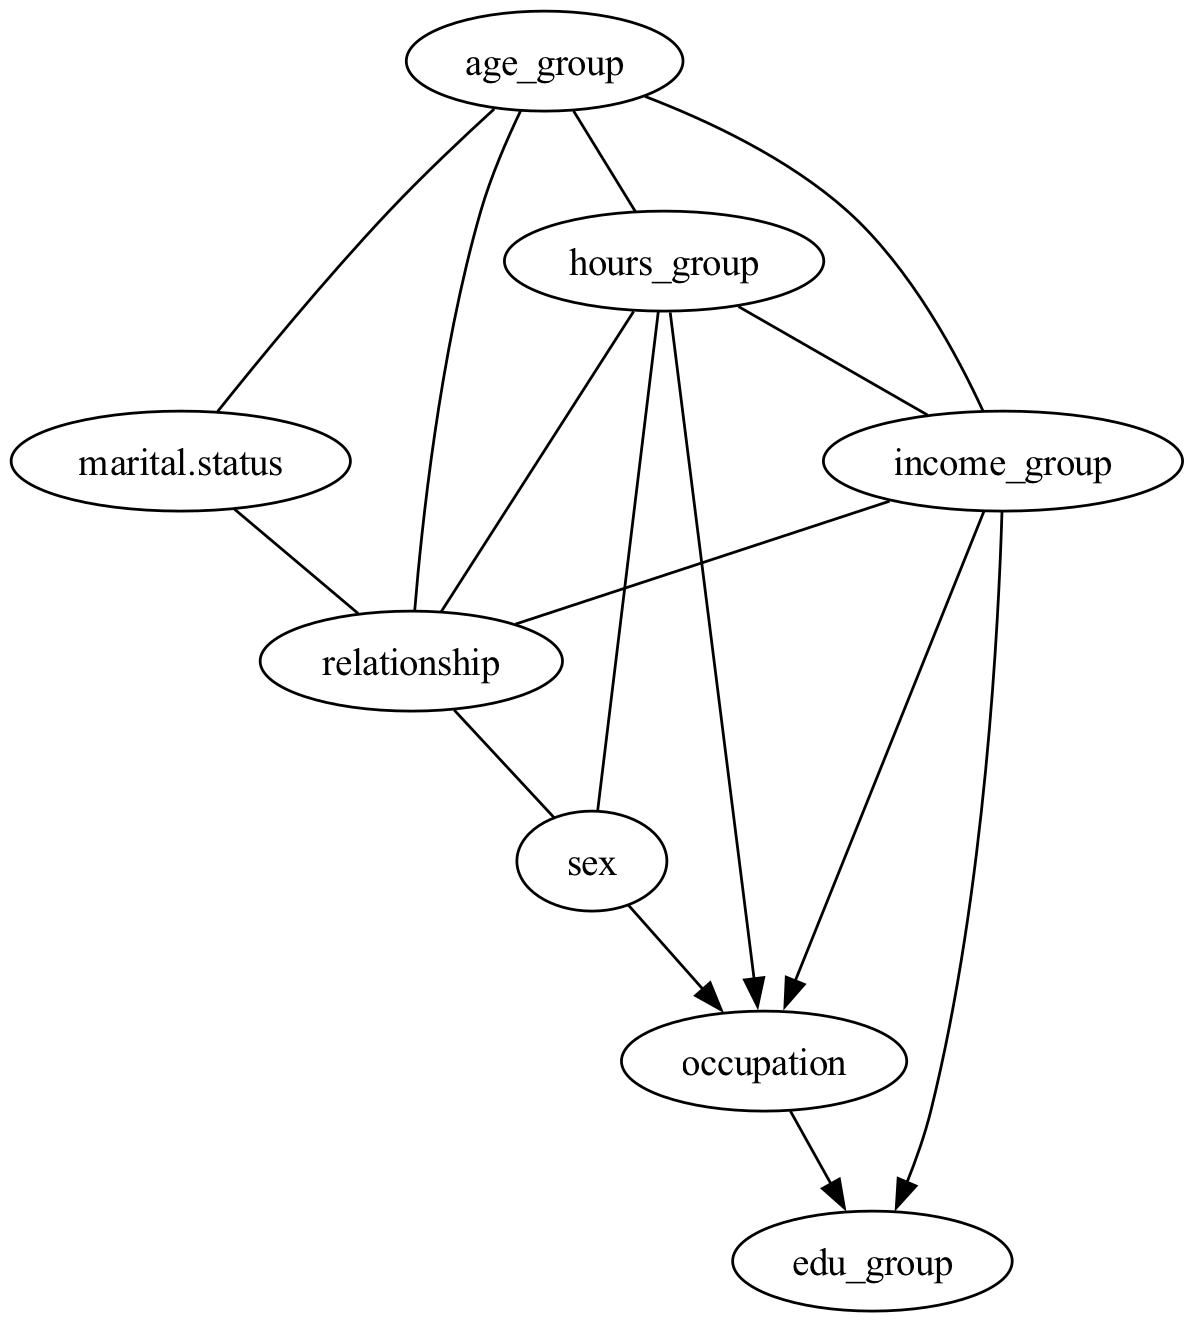

In [9]:
pyd = GraphUtils.to_pydot(G_bdeu, labels=node_names_disc)
display(Image(pyd.create_png()))

### 3b-bis. Post-hoc LLM Orientation of the BDeu CPDAG

The CPDAG above carries many `---` edges because observational data alone cannot tell `A → B` from `B → A`. We use `CausalGraphReviewer` from [src/causal_llm_review/](../src/causal_llm_review/) to ask an LLM to **orient** (or **remove** / **reverse**) every edge using domain knowledge:

1. `decode_adj_matrix(G_bdeu.graph, node_names_disc)` → list of `EdgeInput`
2. `reviewer.review(...)` → one `EdgeDecision` per edge (`keep` / `remove` / `reverse` / `orient`) with reasoning
3. `reviewer.apply_corrections(...)` → patched adjacency, re-wrapped as a `GeneralGraph` for display

Compared with the score-modifying approach in §6c/§6d, this is a **post-hoc** review: it runs *after* GES, on its final CPDAG. That makes it fast and auditable (every change has a one-line LLM rationale) but it cannot influence which edges GES picks in the first place.

In [12]:
from src.causal_llm_review import (
    CausalGraphReviewer, decode_adj_matrix, OpenAIAdapter,
)

# Self-contained: instantiate an adapter here so 3b-bis can run independently of §6.
adapter_review = OpenAIAdapter("gpt-4.1")

DISC_CONTEXT = """
Adult Census Income dataset (1994 US Census Bureau). Variables in this view (all label-encoded):

Binned (named-bucket categoricals):
- age_group:    young / early_career / mid_career / late_career / senior
- edu_group:    below_hs / hs_grad / some_college / bachelors / graduate
- hours_group:  part_time / standard / overtime / heavy
- income_group: low (<=50K) vs high (>50K) — the prediction target

Native categoricals:
- marital.status: Married-civ-spouse / Never-married / Divorced / Separated / Widowed / Married-spouse-absent / Married-AF-spouse
- occupation:     Prof-specialty / Craft-repair / Exec-managerial / Adm-clerical / Sales / Other-service / ... (14 levels)
- relationship:   Husband / Wife / Own-child / Not-in-family / Unmarried / Other-relative

Demographic:
- sex: biological sex (immutable; cannot be an effect of any other variable here)
"""

DOMAIN_RULES = (
    "sex and age_group are immutable demographics — they cannot be caused by anything in this graph.\n"
    "income_group is the outcome; it rarely causes upstream demographics, education, or occupation.\n"
    "relationship is largely a consequence of marital.status (household role follows from marriage status)."
)

reviewer    = CausalGraphReviewer(adapter_review)
edges_bdeu  = decode_adj_matrix(G_bdeu.graph, node_names_disc)
print(f"Sending {len(edges_bdeu)} edges to the LLM for review...")

decisions_bdeu = reviewer.review(
    edges_bdeu,
    node_names_disc,
    dataset_context=DISC_CONTEXT,
    domain_rules=DOMAIN_RULES,
)

df_decisions = pd.DataFrame([
    {
        "before":     f"{d.node_from} {d.original_mark} {d.node_to}",
        "action":     d.action,
        "after":      "—" if d.action == "remove"
                       else f"{d.node_from} {d.corrected_mark} {d.node_to}",
        "confidence": d.confidence,
        "reasoning":  d.reasoning,
    }
    for d in decisions_bdeu
])
pd.set_option("display.max_colwidth", 140)
df_decisions

Sending 15 edges to the LLM for review...


,before,action,after,confidence,reasoning
0,age_group --- hours_group,orient,age_group --> hours_group,medium,"Age group temporally precedes and often influences work hours, as younger and older individuals typically work different amounts due to ..."
1,age_group --- income_group,orient,age_group --> income_group,medium,"Age group temporally precedes income group, as lifetime experience and career progression affect likely earnings, but earnings do not in..."
2,age_group --- marital.status,orient,age_group --> marital.status,medium,"Age is a strong temporal and causal determinant of marital status (e.g., young people are rarely married, senior people are more likely ..."
3,age_group --- relationship,orient,age_group --> relationship,medium,"Age affects likely household roles (young as own child, seniors as widowed), but relationship does not affect age. Age_group --> relatio..."
4,income_group --> edu_group,reverse,income_group <-- edu_group,high,Educational attainment temporally and causally precedes income group; income does not determine one's already-acquired education level. ...
5,occupation --> edu_group,reverse,occupation <-- edu_group,high,"Education typically precedes and largely determines occupation (training requirements, credentials). Occupation rarely, if ever, determi..."
6,hours_group --- income_group,orient,hours_group --> income_group,medium,"Work hours typically influence income, not vice versa, especially in wage/salary contexts. Direction: hours_group --> income_group."
7,hours_group --> occupation,keep,hours_group --> occupation,medium,"Certain occupations are associated with typical work hours, but causation may flow from occupation to hours. However, for this dataset, ..."
8,hours_group --- relationship,orient,hours_group --> relationship,low,"Household relationship often follows from life stage and hours worked, but causality is weak. Likely direction is hours_group --> relati..."
9,hours_group --- sex,remove,—,high,Sex is immutable and cannot be caused by work hours group. Any statistical association is confounded/indirect.


In [14]:
df_decisions.groupby("action").size().sort_values(ascending=False)

action
orient     8
reverse    3
keep       2
remove     2
dtype: int64

── GES + BDeu (original CPDAG) ──────────────────────────────────────────


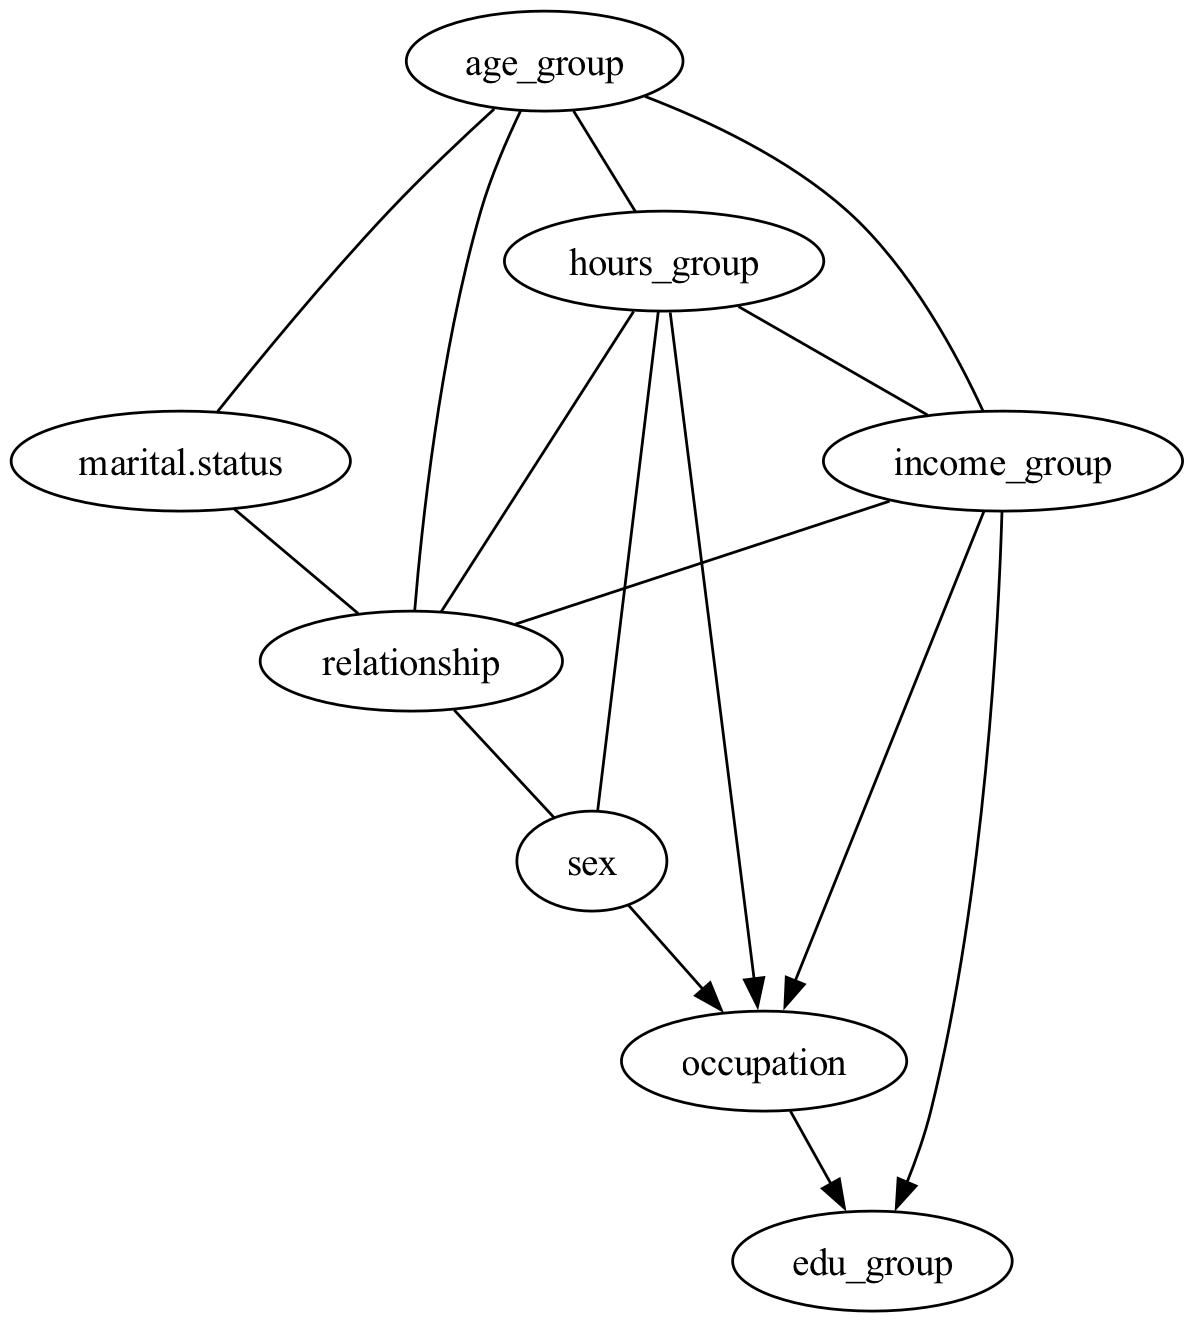

── GES + BDeu after LLM orientation ─────────────────────────────────────


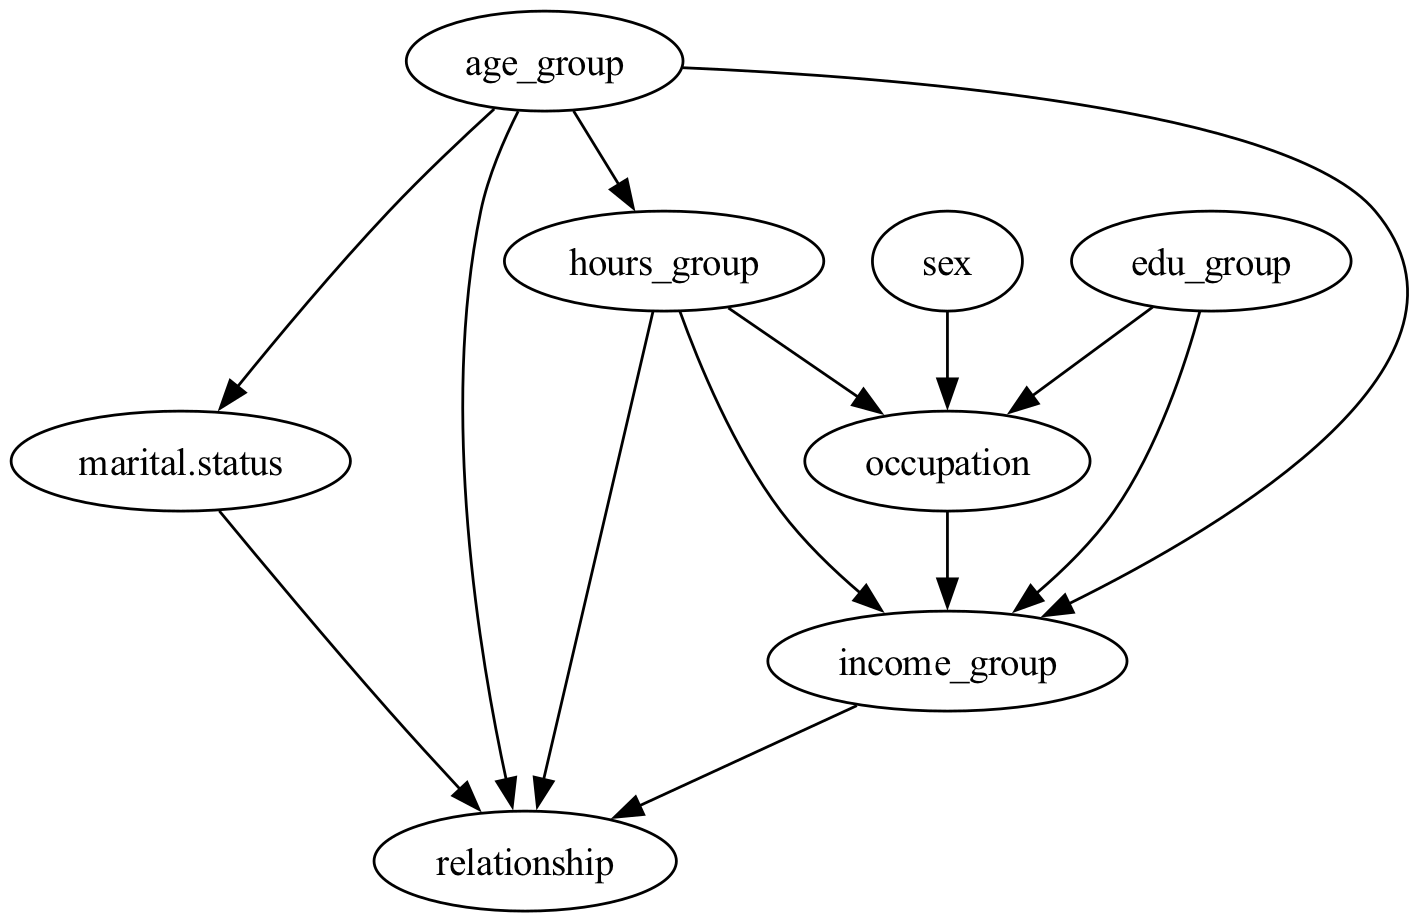


Before: directed=5, undirected=10, total=15
After:  directed=13,  undirected=0, total=13


In [13]:
# Apply corrections and wrap as a GeneralGraph for visualisation
adj_bdeu_llm = reviewer.apply_corrections(G_bdeu.graph, decisions_bdeu, node_names_disc)
G_bdeu_llm   = GeneralGraph([GraphNode(n) for n in node_names_disc])
G_bdeu_llm.graph = adj_bdeu_llm

print("── GES + BDeu (original CPDAG) ──────────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_bdeu, labels=node_names_disc).create_png()))

print("── GES + BDeu after LLM orientation ─────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_bdeu_llm, labels=node_names_disc).create_png()))

# Edge-mark counts before/after
def edge_summary(G):
    n = G.graph.shape[0]
    directed = undirected = 0
    for i in range(n):
        for j in range(i + 1, n):
            a, b = int(G.graph[i, j]), int(G.graph[j, i])
            if (a, b) in {(-1, 1), (1, -1)}:
                directed += 1
            elif (a, b) == (-1, -1):
                undirected += 1
    return directed, undirected

d_before, u_before = edge_summary(G_bdeu)
d_after,  u_after  = edge_summary(G_bdeu_llm)
print(f"\nBefore: directed={d_before}, undirected={u_before}, total={d_before + u_before}")
print(f"After:  directed={d_after},  undirected={u_after}, total={d_after  + u_after}")

### 3c. Mixed Data — Kernel-Based Score (`local_score_CV_general`)

Both BIC and BDeu force a parametric assumption (linear Gaussian / discrete multinomial). When the data is *mixed* — some genuinely continuous (`age`, `hours.per.week`) and some integer-coded categoricals (`sex`, `marital.status`) — neither is a clean fit.

`local_score_CV_general` is a **nonparametric** score: for each variable it fits an RKHS regression (kernel ridge with Gaussian kernels) on its parents and returns the k-fold cross-validated log-likelihood. The kernel doesn't care whether an integer code is "really" categorical — only whether the conditional expectation is smooth.

**Trade-off**: kernel matrix inversion is O(n³) per local score call.  
Infeasible on 32 561 rows; tractable on a subsample.

| Setting | Value | Why |
|---------|-------|-----|
| Subsample | 1 500 rows | Keeps kernel matrices small enough for L-BFGS inversion (~1.5 min total) |
| `kfold` | 2 | Half the work of default 10-fold; CV estimate still stable |
| `lambda` | 0.01 | Standard ridge regularisation |

In [ ]:
# Random subsample of the 8-var mixed subset.
# We cast to float because kernel regression operates in R^d — but the kernel
# itself is happy to consume integer-coded categoricals.
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(data_disc), size=5000, replace=False)
data_mixed = data_disc[sample_idx].astype(float)

print(f"Subsample: {data_mixed.shape}")

record_kernel = ges(
    data_mixed,
    score_func="local_score_CV_general",
    parameters={"kfold": 2, "lambda": 0.01},
    node_names=node_names_disc,
)

G_kernel = record_kernel["G"]

print("\nEdge list (GES – CV kernel, CPDAG):")
for edge in G_kernel.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_kernel.get_graph_edges())}  |  score: {record_kernel['score']:.1f}")

In [ ]:
pyd = GraphUtils.to_pydot(G_kernel, labels=node_names_disc)
display(Image(pyd.create_png()))

## 4. Continuous Optimisation: NOTEARS

**NOTEARS** (Zheng et al., NeurIPS 2018) reformulates DAG structure learning as a *continuous* optimisation problem,  
bypassing the combinatorial search over DAGs entirely.

The key idea is a smooth acyclicity characterisation:
$$h(W) = \operatorname{tr}\!\bigl(e^{W \circ W}\bigr) - d = 0 \iff W \text{ is a DAG}$$

The objective is minimised via augmented Lagrangian:
$$\min_W \;\frac{1}{2n}\|X - XW\|_F^2 + \lambda_1 \|W\|_1 \quad\text{s.t.}\quad h(W) = 0$$

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 sparsity penalty (larger → fewer edges) |
| `loss_type` | `l2` for linear Gaussian, `logistic` for binary |
| `w_threshold` | Drop edge if \|weight\| < threshold after optimisation |

**Output**: a *weighted* DAG (not a CPDAG) — edge directions are fully committed.

In [16]:
W_notears = notears_linear(
    data_cont,
    lambda1=0.1,
    loss_type="l2",
    w_threshold=0.3,
)

d = len(node_names_cont)

print("NOTEARS edges (DAG, weighted):")
n_edges = 0
for i in range(d):
    for j in range(d):
        if W_notears[i, j] != 0:
            print(f"  {node_names_cont[i]} --> {node_names_cont[j]}  (weight = {W_notears[i, j]:.3f})")
            n_edges += 1

print(f"\nTotal edges: {n_edges}")

NOTEARS edges (DAG, weighted):
  age --> capital.gain  (weight = 39.046)
  age --> capital.loss  (weight = 1.633)
  education.num --> capital.gain  (weight = 330.421)
  education.num --> capital.loss  (weight = 12.053)
  education.num --> hours.per.week  (weight = 0.622)
  capital.loss --> capital.gain  (weight = -0.882)
  hours.per.week --> capital.gain  (weight = 35.305)
  hours.per.week --> capital.loss  (weight = 1.402)

Total edges: 8


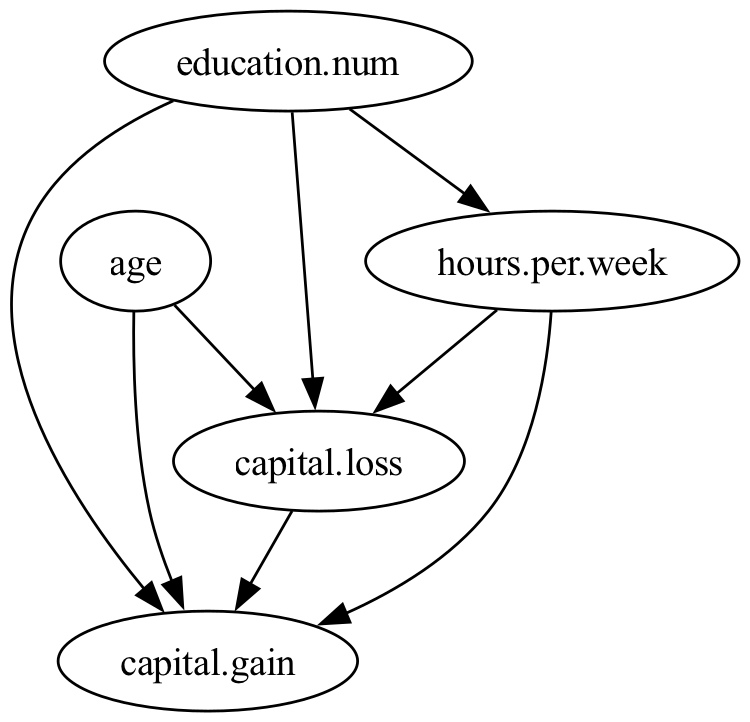

In [17]:
# Convert W_notears to a causal-learn GeneralGraph for consistent visualisation.
# W_notears[i, j] != 0  means  i --> j
# causal-learn encoding for i --> j: graph[i,j] = -1, graph[j,i] = 1
nodes_obj  = [GraphNode(n) for n in node_names_cont]
G_notears  = GeneralGraph(nodes_obj)
adj_notears = np.zeros((d, d), dtype=int)
for i in range(d):
    for j in range(d):
        if W_notears[i, j] != 0:
            adj_notears[i, j] = -1
            adj_notears[j, i] = 1
G_notears.graph = adj_notears

pyd = GraphUtils.to_pydot(G_notears, labels=node_names_cont)
display(Image(pyd.create_png()))

## 5. Permutation-Based: GRaSP

**GRaSP** (Greedy Relaxations of the Sparsest Permutation, Lam et al. 2022) searches over  
*variable orderings* (permutations) rather than directly over edges.

The key insight: any topological ordering of a DAG defines a valid causal order.  
GRaSP greedily improves the ordering by swapping pairs of variables, measuring improvement via a BIC-like score.

| Aspect | GES | GRaSP |
|--------|-----|-------|
| Search space | Equivalence classes of DAGs | Permutations |
| Score | BIC on DAG edges | BIC on topological order |
| Acyclicity | Guaranteed by equivalence-class operators | Guaranteed by ordering |
| Output | CPDAG | CPDAG |

> **Note on default λ**: GRaSP defaults to `lambda_value=2.0` (vs GES's `0.5`).  
> To compare fairly, we set `lambda_value=0.5` here.

In [18]:
G_grasp = grasp(
    data_cont,
    score_func="local_score_BIC_from_cov",
    parameters={"lambda_value": 0.5},   # match GES default for a fair comparison
    node_names=node_names_cont,
    verbose=False,
)

print("Edge list (GRaSP – BIC, CPDAG):")
for edge in G_grasp.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_grasp.get_graph_edges())}")

Edge list (GRaSP – BIC, CPDAG):
  age --- capital.gain
  age --- capital.loss
  age --- hours.per.week
  education.num --- capital.gain
  education.num --- capital.loss
  education.num --- hours.per.week
  capital.gain --- capital.loss
  capital.gain --- hours.per.week
  capital.loss --- hours.per.week

Total edges: 9


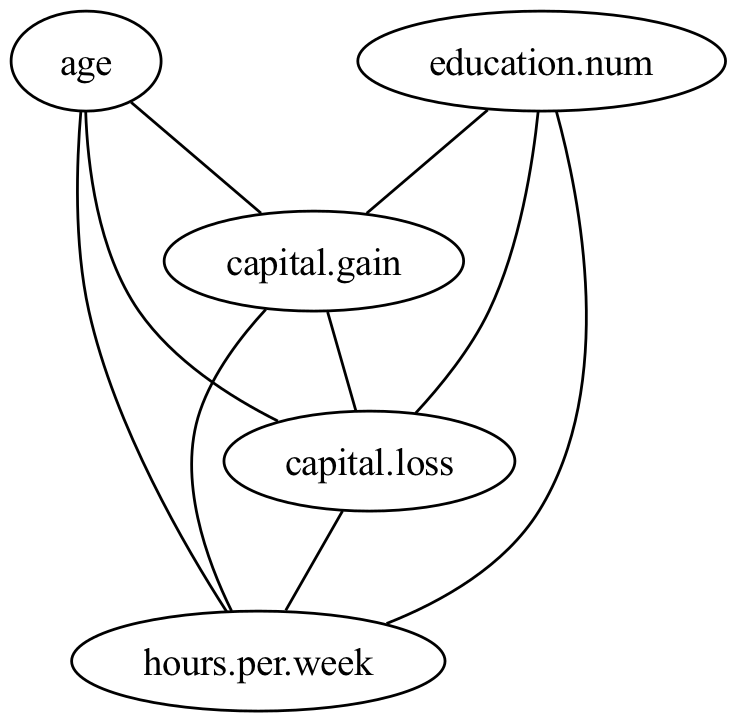

In [19]:
pyd = GraphUtils.to_pydot(G_grasp, labels=node_names_cont)
display(Image(pyd.create_png()))

Edge list (GRaSP – BDeu on discrete data, CPDAG):
  age_group --- marital.status
  age_group --- relationship
  age_group --- sex
  income_group --> edu_group
  occupation --> edu_group
  hours_group --- occupation
  hours_group --- relationship
  hours_group --- sex
  occupation --> income_group
  relationship --> income_group
  marital.status --- relationship
  occupation --- sex
  relationship --- sex

Total edges: 13


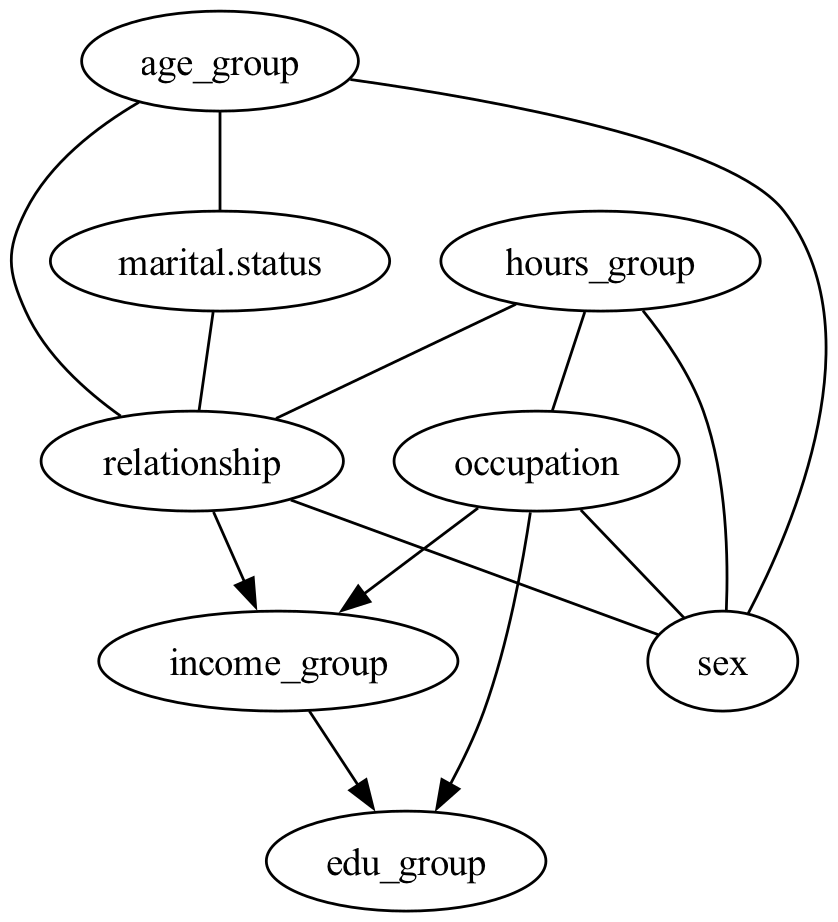

In [21]:
# GRaSP is search-agnostic about data type — swap the score function to handle discrete data.
# Same permutation-based search, but now using BDeu over the 8-column label-encoded subset.
G_grasp_disc = grasp(
    data_disc,
    score_func="local_score_BDeu",
    node_names=node_names_disc,
    verbose=False,
)

print("Edge list (GRaSP – BDeu on discrete data, CPDAG):")
for edge in G_grasp_disc.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_grasp_disc.get_graph_edges())}")

display(Image(GraphUtils.to_pydot(G_grasp_disc, labels=node_names_disc).create_png()))

## 6. Modifying the Score

Score-based algorithms use a local score function with signature:
```python
score_fn(Data, i, PAi, parameters) -> float
```
- `Data`: raw data matrix `(n_samples × n_features)`
- `i`: target variable index
- `PAi`: list of parent indices  
- `parameters`: dict of extra config

By replacing this function we can inject any prior knowledge directly into the search,  
making it influence the graph *during* structure learning rather than as a post-hoc correction.

**How we bypass GES's string dispatch**  
GES selects the score function by string name and raises `ValueError` for unknown names.  
The workaround: temporarily replace the module-level reference to `local_score_BIC_from_cov`  
(or `local_score_BDeu`) in GES's namespace — Python resolves global lookups at call time,  
so the running `ges()` call picks up our patched function.

In [22]:
import causallearn.search.ScoreBased.GES as _ges_mod


def run_ges_custom(data, custom_score_fn, base_score_name, node_names=None, parameters=None):
    """
    Run GES with a custom local score function.

    Parameters
    ----------
    data : np.ndarray
    custom_score_fn : callable
        Signature: (Data: np.ndarray, i: int, PAi: list, parameters) -> float
        The function receives *raw data* (not a covariance tuple).
    base_score_name : str
        GES dispatch key to activate: "local_score_BIC_from_cov" or "local_score_BDeu".
    node_names : list, optional
    parameters : dict, optional

    Returns
    -------
    dict — same structure as ges() return value, with key "G" for the resulting graph.
    """
    orig_fn = getattr(_ges_mod, base_score_name)
    setattr(_ges_mod, base_score_name, custom_score_fn)
    try:
        if base_score_name == "local_score_BIC_from_cov":
            score_str = "local_score_BIC"
        else:
            score_str = base_score_name
        record = ges(data, score_func=score_str, node_names=node_names, parameters=parameters)
    finally:
        setattr(_ges_mod, base_score_name, orig_fn)
    return record

### 6a. Prior-Augmented BDeu — Encoding Background Knowledge in the Score

In the constraint-based notebook we used `BackgroundKnowledge` to forbid edges *into* immutable variables  
(`sex`, `age`) after structure learning. Here we encode the same constraint **inside the score itself**:
a large additive penalty discourages any parent from being assigned to an immutable variable.

This approach:
- Applies continuously during search (not as a post-filter)
- Allows *soft* enforcement (tune the penalty magnitude)
- Works without modifying the search algorithm

In [31]:
# ── Hard immutability constraint via score injection ────────────────────────
# GES in this causal-learn version does NOT accept BackgroundKnowledge — the
# constraint has to be encoded in the score function. Two things matter:
#   1. The per-variable penalty must DOMINATE any realistic BDeu score change
#      (BDeu values can themselves reach 1e5 on 30k rows, so 1e18 is a safe choice).
#   2. After GES finishes, `dag2cpdag` may convert edges touching immutables into
#      undirected ones (---), which renderers draw with arrowheads on both ends.
#      We post-process to force every such edge to point OUT of the immutable.
IMMUTABLE     = ["sex", "age_group"]
IMMUTABLE_IDX = [node_names_disc.index(n) for n in IMMUTABLE]
IMMUTABILITY_PEN = 1e18   # truly dominant — larger than any BDeu score difference

_bdeu_orig = local_score_BDeu


def local_score_BDeu_with_prior(Data, i, PAi, parameters=None):
    """BDeu with a hard constraint: parents of immutable variables are forbidden."""
    if i in IMMUTABLE_IDX and len(PAi) > 0:
        return _bdeu_orig(Data, i, PAi, parameters) - IMMUTABILITY_PEN
    return _bdeu_orig(Data, i, PAi, parameters)


def force_immutable_as_source(G, node_names, immutable_names):
    """Orient every edge touching an immutable so the immutable is the source.
    Needed because dag2cpdag can leave such edges undirected in the CPDAG."""
    immutable = {node_names.index(n) for n in immutable_names}
    n = len(node_names)
    for i in range(n):
        for j in range(i + 1, n):
            if G.graph[i, j] == 0 and G.graph[j, i] == 0:
                continue
            if i in immutable and j not in immutable:
                G.graph[i, j], G.graph[j, i] = -1, 1   # i --> j
            elif j in immutable and i not in immutable:
                G.graph[i, j], G.graph[j, i] = 1, -1   # j --> i
    return G


record_prior = run_ges_custom(
    data_disc,
    custom_score_fn=local_score_BDeu_with_prior,
    base_score_name="local_score_BDeu",
    node_names=node_names_disc,
)
G_prior = record_prior["G"]
force_immutable_as_source(G_prior, node_names_disc, IMMUTABLE)

print("Edge list (GES – BDeu + hard immutability + source-orientation):")
for edge in G_prior.get_graph_edges():
    print(f"  {edge}")

print(f"\nTotal edges: {len(G_prior.get_graph_edges())}")

print("\nEdges touching immutable variables (must all be OUT of sex / age_group):")
found = False
for edge in G_prior.get_graph_edges():
    s = str(edge)
    if any(name in s for name in IMMUTABLE):
        print(f"  {s}")
        found = True
if not found:
    print("  (none — immutables ended up disconnected)")

Edge list (GES – BDeu + hard immutability + source-orientation):
  age_group --> hours_group
  age_group --> income_group
  age_group --> marital.status
  age_group --> relationship
  income_group --> edu_group
  occupation --> edu_group
  income_group --> hours_group
  hours_group --- occupation
  hours_group --- relationship
  sex --> hours_group
  income_group --> occupation
  income_group --> relationship
  relationship --> marital.status
  sex --> occupation
  sex --> relationship

Total edges: 15

Edges touching immutable variables (must all be OUT of sex / age_group):
  age_group --> hours_group
  age_group --> income_group
  age_group --> marital.status
  age_group --> relationship
  sex --> hours_group
  sex --> occupation
  sex --> relationship


── Standard GES (BDeu) ──────────────────────────────────────────────────


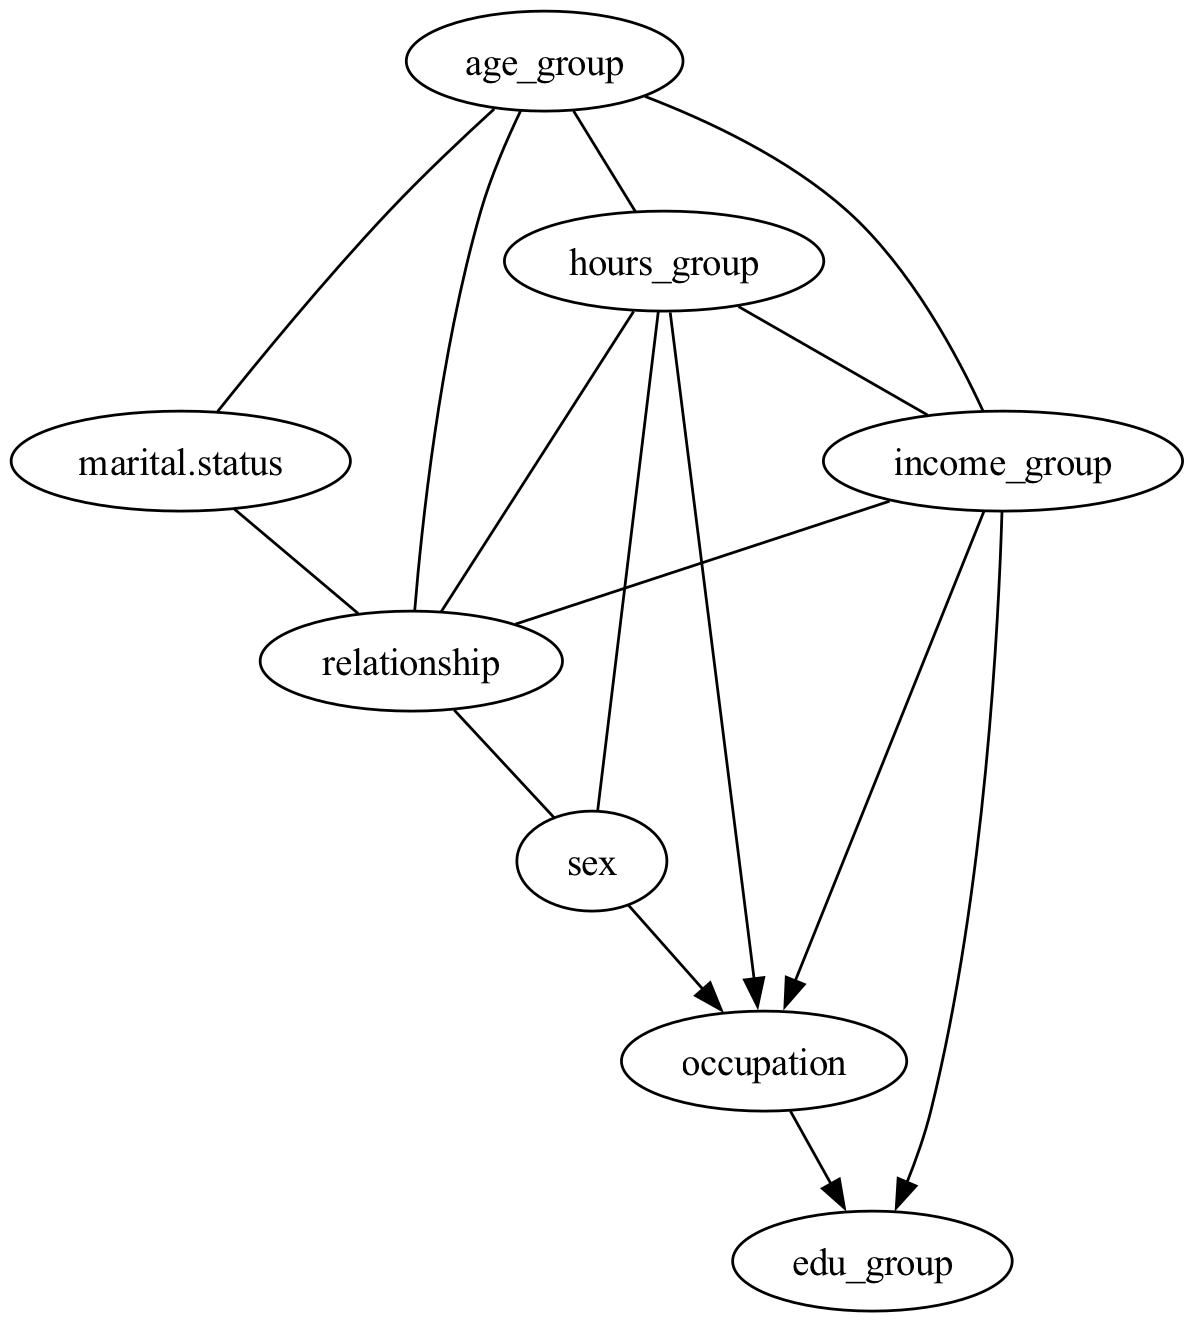

── GES with immutability prior ──────────────────────────────────────────


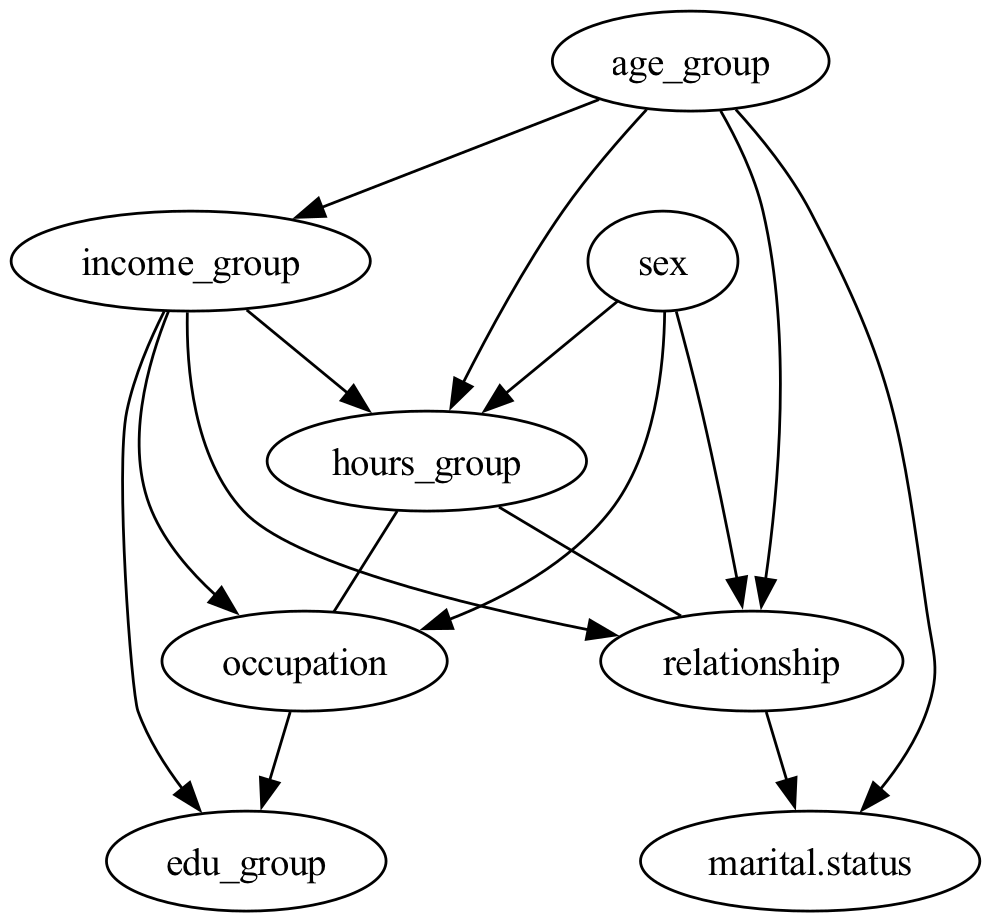

In [32]:
# Side-by-side: standard BDeu vs prior-augmented BDeu
print("── Standard GES (BDeu) ──────────────────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_bdeu, labels=node_names_disc).create_png()))

print("── GES with immutability prior ──────────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_prior, labels=node_names_disc).create_png()))

### 6b. LLM-Derived Penalty Matrix — Setup

Instead of hand-crafting domain rules, we query an LLM for a *plausibility penalty* for every candidate directed edge. The resulting `penalty_matrix` is consumed by the score-based methods in **6c (GRaSP)** and **6d (NOTEARS)**.

**Pipeline:**
1. Enumerate all `n*(n-1)` directed pairs for the continuous variables (5×4 = 20 pairs)
2. Send them to the LLM in one structured call — returns a penalty in [0, 10] per pair
3. Store as a `penalty_matrix[i, j]` (rows = source, cols = target)

> **Why we don't pair this with GES.** GES assumes Markov-equivalent DAGs share a score; a per-direction LLM penalty silently violates that assumption. In practice, GES then locks in *implausible* orientations rather than plausible ones. We pair the LLM penalty with algorithms that don't make this assumption: GRaSP (permutation-based) and NOTEARS (continuous DAG optimisation).

In [27]:
from src.causal_llm_review import OpenAIAdapter, AnthropicAdapter
from src.causal_llm_review.models import EdgePenaltyResponse

# ── Pick a provider (swap this one line) ─────────────────────────────────────
adapter = OpenAIAdapter("gpt-4.1")   # reads secrets/secrets.yaml

DATASET_CONTEXT = """
Adult Census Income dataset (1994 US Census Bureau).
Prediction task: whether a person earns >$50K/year.

Variables (continuous subset used here):
- age: person's age in years (range 17–90)
- education.num: numeric education level 1–16
  (1=Preschool, 9=HS-grad, 13=Bachelors, 16=Doctorate)
- capital.gain: net capital gains from investments ($)
- capital.loss: net capital losses from investments ($)
- hours.per.week: usual weekly work hours (1–99)
"""

In [28]:
def build_llm_penalty_matrix(node_names, adapter, dataset_context):
    """
    Query the LLM for a plausibility penalty for every directed pair of variables.

    Returns
    -------
    penalty_matrix : np.ndarray, shape (n, n)
        penalty_matrix[i, j] = penalty for edge i -> j  (range 0–10)
    response : EdgePenaltyResponse
    """
    n     = len(node_names)
    pairs = [(f, t) for f in node_names for t in node_names if f != t]

    system = (
        "You are a domain expert in labor economics and sociology.\n"
        "\n"
        "Your task: for each proposed DIRECTED causal edge X --> Y, return ALL FOUR fields:\n"
        "  - node_from: the source variable name (copy exactly)\n"
        "  - node_to:   the target variable name (copy exactly)\n"
        "  - penalty:   a float in [0, 10] scoring how implausible the direction is:\n"
        "      0  = very plausible — natural causal direction\n"
        "      5  = uncertain — both directions possible\n"
        "      10 = implausible or impossible — contradicts known causal ordering\n"
        "  - reasoning: a 1–2 sentence explanation grounded in domain knowledge\n"
        "\n"
        "Every entry MUST include all four fields. Do not omit penalty or reasoning.\n"
        "Be consistent: if X-->Y scores 0, then Y-->X should score ~10, and vice versa."
    )

    pair_lines = "\n".join(f"  {i+1}. {f} --> {t}" for i, (f, t) in enumerate(pairs))
    user = (
        f"Dataset context:\n{dataset_context}\n\n"
        f"Call edge_penalties with one EdgePenalty object per edge, "
        f"in the same order. Each object MUST contain node_from, node_to, "
        f"penalty (0–10), and reasoning.\n\n"
        f"Edges to evaluate ({len(pairs)} total):\n{pair_lines}"
    )

    raw = adapter.complete_with_tool(
        system=system,
        user=user,
        json_schema=EdgePenaltyResponse.model_json_schema(),
        tool_name="edge_penalties",
        tool_desc=(
            "Return a plausibility penalty for each proposed causal edge. "
            "Each penalty object must include node_from, node_to, penalty (float 0–10), "
            "and reasoning (1–2 sentences)."
        ),
    )

    response = EdgePenaltyResponse(**raw)

    name_to_idx   = {name: i for i, name in enumerate(node_names)}
    penalty_matrix = np.zeros((n, n))
    for ep in response.penalties:
        i = name_to_idx.get(ep.node_from)
        j = name_to_idx.get(ep.node_to)
        if i is not None and j is not None and i != j:
            penalty_matrix[i, j] = ep.penalty

    return penalty_matrix, response

In [29]:
penalty_matrix, llm_response = build_llm_penalty_matrix(
    node_names_cont, adapter, DATASET_CONTEXT)

# Display as a DataFrame for inspection
df_penalty = pd.DataFrame(
    penalty_matrix, index=node_names_cont, columns=node_names_cont
).round(1)
print("LLM penalty matrix (rows = source, cols = target, higher = more implausible):")
df_penalty

LLM penalty matrix (rows = source, cols = target, higher = more implausible):


,age,education.num,capital.gain,capital.loss,hours.per.week
age,0.0,2.0,2.0,2.0,2.0
education.num,10.0,0.0,1.0,1.0,3.0
capital.gain,10.0,7.0,0.0,5.0,6.0
capital.loss,10.0,7.0,5.0,0.0,6.0
hours.per.week,10.0,8.0,7.0,7.0,0.0


In [33]:
# Visualise the penalty matrix as an interactive plotly heatmap
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=penalty_matrix,
    x=node_names_cont,
    y=node_names_cont,
    zmin=0, zmax=10,
    colorscale="RdYlGn",
    reversescale=True,
    colorbar=dict(title="Penalty"),
    text=np.round(penalty_matrix, 1),
    texttemplate="%{text}",
    hovertemplate="%{y} → %{x}<br>penalty: %{z:.1f}<extra></extra>",
))
fig.update_layout(
    title="LLM edge penalty matrix  (row → col, 0 = plausible, 10 = implausible)",
    xaxis=dict(title="To",   tickangle=45),
    yaxis=dict(title="From", autorange="reversed"),
    width=600, height=500,
)
fig.show()

In [34]:
# Show LLM reasoning for all edges
df_llm_reasoning = pd.DataFrame([
    {"Edge": f"{ep.node_from} --> {ep.node_to}",
     "Penalty": ep.penalty,
     "Reasoning": ep.reasoning}
    for ep in llm_response.penalties
])
pd.set_option("display.max_colwidth", 150)
df_llm_reasoning.sort_values("Penalty", ascending=False)

,Edge,Penalty,Reasoning
12,capital.loss --> age,10.0,Experiencing a capital loss does not cause a person to age; causality in this direction is implausible.
4,education.num --> age,10.0,"Education level does not deterministically influence age; one can achieve a given level of education at many ages, so causality from education.lev..."
16,hours.per.week --> age,10.0,"Working more or fewer hours does not affect a person's chronological age, making this direction implausible."
8,capital.gain --> age,10.0,Capital gains do not influence a person's age; causality in this direction is implausible.
17,hours.per.week --> education.num,8.0,Usual weekly hours worked do not causally drive one's completed education; the reverse is more plausible.
19,hours.per.week --> capital.loss,7.0,Hours worked per week do not causally increase or decrease capital losses; this direction is implausible except under rare scenarios.
18,hours.per.week --> capital.gain,7.0,"Weekly work hours weakly correlate with labor income but are not a major pathway for capital gains, which mostly derive from investments."
9,capital.gain --> education.num,7.0,"Having higher capital gain does not generally affect one's educational attainment, except perhaps if investment wealth allows further education, b..."
13,capital.loss --> education.num,7.0,"Capital losses do not causally affect educational attainment except in rare cases (e.g., if severe loss interrupts education), so this edge is gen..."
15,capital.loss --> hours.per.week,6.0,"Having a capital loss doesn't directly influence hours worked, except in rare cases where losses prompt increased labor supply, so this is not a s..."


In [39]:
# ── Custom BIC + LLM score ────────────────────────────────────────────────────
# Consumed by 6c (GRaSP). Penalty matrix and scale captured via closure.
_llm_penalty_matrix = penalty_matrix
LLM_PENALTY_SCALE   = 5.0   # map LLM [0-10] → BIC units; tune for desired influence

_bic_orig = local_score_BIC


def local_score_BIC_llm(Data, i, PAi, parameters=None):
    """BIC augmented with LLM-derived plausibility penalties for each parent."""
    base = _bic_orig(Data, i, PAi, parameters)
    if len(PAi) == 0:
        return base
    # For each parent p of i, subtract penalty_matrix[p, i] — the penalty for edge p → i.
    llm_penalty = LLM_PENALTY_SCALE * sum(_llm_penalty_matrix[p, i] for p in PAi)
    return base - llm_penalty

In [40]:
# Helper used in 6c to diff two CPDAGs by edge mark
def adj_edges(G, node_names):
    """Return a set of (from, to, mark) triples for a CPDAG."""
    n = len(node_names)
    out = []
    for i in range(n):
        for j in range(i + 1, n):
            a, b = int(G.graph[i, j]), int(G.graph[j, i])
            if a == -1 and b == 1:
                out.append((node_names[i], node_names[j], "-->"))
            elif a == 1 and b == -1:
                out.append((node_names[j], node_names[i], "-->"))
            elif a == -1 and b == -1:
                out.append((node_names[i], node_names[j], "---"))
    return set(out)

### 6c. LLM Penalty with GRaSP — Layered on Prior Knowledge

**Why GRaSP fits the LLM penalty.** GES assumes Markov-equivalent DAGs share a score; a per-direction LLM penalty silently violates that. GRaSP searches over **permutations** instead — a permutation already commits to direction, so a direction-dependent score is *natural* rather than an axiom violation.

**Prior knowledge baked into both runs.** The §6a immutability prior (no parents for `sex` and `age_group`) is folded into the score for both the baseline and the LLM-augmented run, so the comparison isolates the LLM contribution rather than confounding it with the prior. Two scores are defined:

- `local_score_BDeu_immutable` — BDeu + hard immutability (the baseline)
- `local_score_BDeu_immutable_llm` — same, plus per-edge LLM plausibility penalty

**Why we also extract the internal DAG.** GRaSP's permutation defines a complete DAG, but its output passes through `dag2cpdag` which strips any orientation that isn't forced by v-structures or Meek's rules. To see what the LLM actually steered, we intercept `dag2cpdag` and return both:

- **CPDAG** (`G_grasp_llm`): the normal GRaSP output — only data-identifiable orientations.
- **Internal DAG** (`G_grasp_llm_dag`): every edge oriented, picked by the LLM-shaped permutation.

Edges directed in the DAG but undirected in the CPDAG are exactly the orientations the **LLM implicitly chose** but that observational data alone cannot identify.

In [44]:
# ── Build a discrete LLM penalty matrix + scores that combine prior knowledge with LLM ──
# Two custom scores share the same hard immutability constraint (from §6a) so the
# baseline and the LLM-augmented run are directly comparable:
#   - local_score_BDeu_immutable      : BDeu + hard "no parents for sex / age_group"
#   - local_score_BDeu_immutable_llm  : same + per-edge LLM plausibility penalty
#
# `adapter`, `build_llm_penalty_matrix`, and `DISC_CONTEXT` come from §6b and §3b-bis.
penalty_matrix_disc, llm_response_disc = build_llm_penalty_matrix(
    node_names_disc, adapter, DISC_CONTEXT,
)

LLM_PENALTY_SCALE_DISC = 5.0
IMMUTABLE_DISC         = ["sex", "age_group"]
IMMUTABLE_DISC_IDX     = [node_names_disc.index(n) for n in IMMUTABLE_DISC]
IMMUTABILITY_PEN_DISC  = 1e18   # truly dominant — encodes a hard constraint

_bdeu_for_combined = local_score_BDeu


def local_score_BDeu_immutable(Data, i, PAi, parameters=None):
    """Prior-knowledge baseline: BDeu with hard immutability for sex and age_group."""
    if i in IMMUTABLE_DISC_IDX and len(PAi) > 0:
        return _bdeu_for_combined(Data, i, PAi, parameters) - IMMUTABILITY_PEN_DISC
    return _bdeu_for_combined(Data, i, PAi, parameters)


def local_score_BDeu_immutable_llm(Data, i, PAi, parameters=None):
    """Prior knowledge + LLM penalty layered on top."""
    base = local_score_BDeu_immutable(Data, i, PAi, parameters)
    if len(PAi) == 0:
        return base
    llm_penalty = LLM_PENALTY_SCALE_DISC * sum(penalty_matrix_disc[p, i] for p in PAi)
    return base - llm_penalty


# ── Generalised GRaSP wrapper that captures the internal DAG ─────────────────
import causallearn.search.PermutationBased.GRaSP as _grasp_mod


def run_grasp_capture_dag(data, custom_score_fn, node_names,
                          base_score_attr, parameters=None):
    """Run GRaSP with a custom score; return (CPDAG, internal DAG before dag2cpdag)."""
    captured = {}
    orig_dag2cpdag = _grasp_mod.dag2cpdag
    orig_score_fn  = getattr(_grasp_mod, base_score_attr)

    def _capture(G):
        dag_copy = GeneralGraph([GraphNode(n) for n in node_names])
        dag_copy.graph = G.graph.copy()
        captured["dag"] = dag_copy
        return orig_dag2cpdag(G)

    _grasp_mod.dag2cpdag = _capture
    setattr(_grasp_mod, base_score_attr, custom_score_fn)
    try:
        G_cpdag = grasp(
            data,
            score_func=base_score_attr,
            node_names=node_names,
            parameters=parameters,
            verbose=False,
        )
    finally:
        _grasp_mod.dag2cpdag = orig_dag2cpdag
        setattr(_grasp_mod, base_score_attr, orig_score_fn)
    return G_cpdag, captured["dag"]


# ── Baseline: GRaSP + BDeu + immutability prior (no LLM) ─────────────────────
G_grasp_prior, _ = run_grasp_capture_dag(
    data_disc,
    custom_score_fn=local_score_BDeu_immutable,
    node_names=node_names_disc,
    base_score_attr="local_score_BDeu",
)
force_immutable_as_source(G_grasp_prior, node_names_disc, IMMUTABLE_DISC)

# ── Combined: GRaSP + BDeu + immutability prior + LLM penalty ────────────────
G_grasp_llm, G_grasp_llm_dag = run_grasp_capture_dag(
    data_disc,
    custom_score_fn=local_score_BDeu_immutable_llm,
    node_names=node_names_disc,
    base_score_attr="local_score_BDeu",
)
# Apply the same source-orientation post-process to the CPDAG.
# The internal DAG already respects the constraint by construction (score = -inf).
force_immutable_as_source(G_grasp_llm, node_names_disc, IMMUTABLE_DISC)

print("Baseline CPDAG (BDeu + prior):")
for edge in G_grasp_prior.get_graph_edges():
    print(f"  {edge}")
print(f"  -> {len(G_grasp_prior.get_graph_edges())} edges")

print("\nLLM-augmented CPDAG (BDeu + prior + LLM):")
for edge in G_grasp_llm.get_graph_edges():
    print(f"  {edge}")
print(f"  -> {len(G_grasp_llm.get_graph_edges())} edges")

print("\nLLM-augmented internal DAG (every edge oriented):")
for edge in G_grasp_llm_dag.get_graph_edges():
    print(f"  {edge}")
print(f"  -> {len(G_grasp_llm_dag.get_graph_edges())} edges")

Baseline CPDAG (BDeu + prior):
  edu_group --- occupation
  hours_group --- income_group
  hours_group --- occupation
  income_group --- occupation
  income_group --- relationship
  marital.status --- relationship
  occupation --- relationship
  -> 7 edges

LLM-augmented CPDAG (BDeu + prior + LLM):
  edu_group --- income_group
  edu_group --- occupation
  hours_group --- income_group
  hours_group --- occupation
  hours_group --- relationship
  sex --> hours_group
  income_group --- occupation
  income_group --- relationship
  sex --> income_group
  marital.status --- relationship
  sex --> marital.status
  sex --> occupation
  sex --> relationship
  -> 13 edges

LLM-augmented internal DAG (every edge oriented):
  income_group --> edu_group
  occupation --> edu_group
  hours_group --> income_group
  occupation --> hours_group
  hours_group --> relationship
  sex --> hours_group
  occupation --> income_group
  income_group --> relationship
  sex --> income_group
  relationship --> marit

── GRaSP + BDeu + prior (CPDAG, baseline) ───────────────────────────────


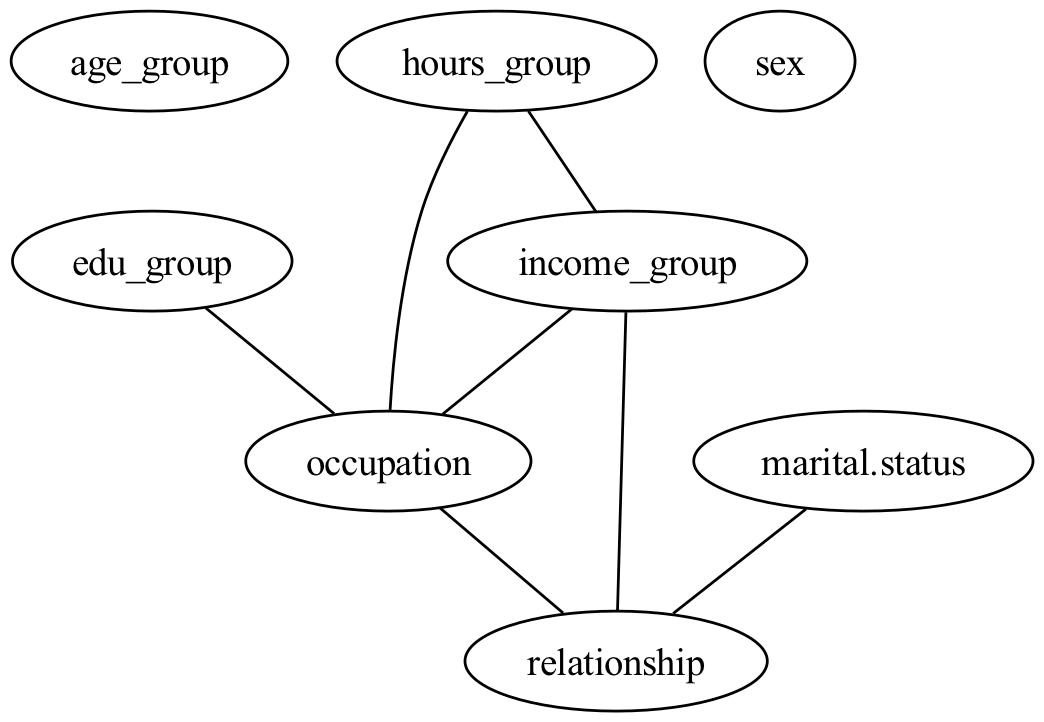

── GRaSP + BDeu + prior + LLM penalty — CPDAG output ────────────────────


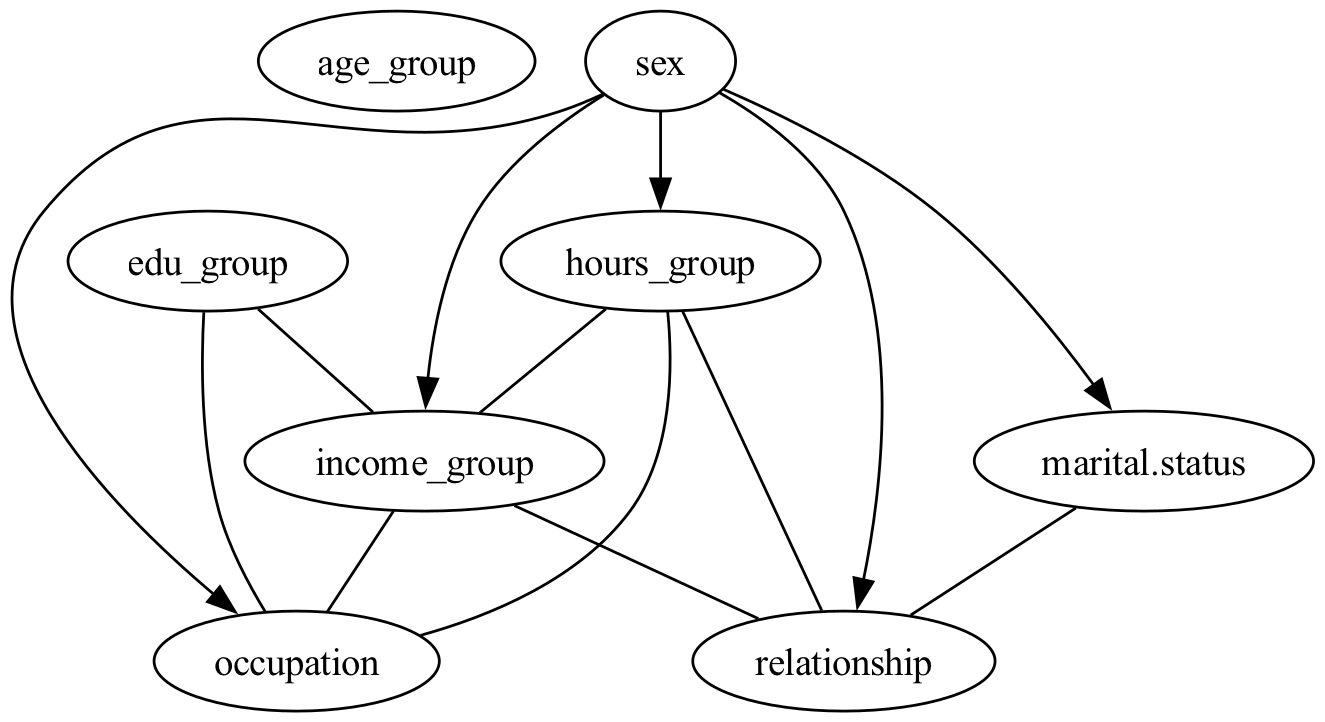

── GRaSP + BDeu + prior + LLM penalty — internal DAG ────────────────────


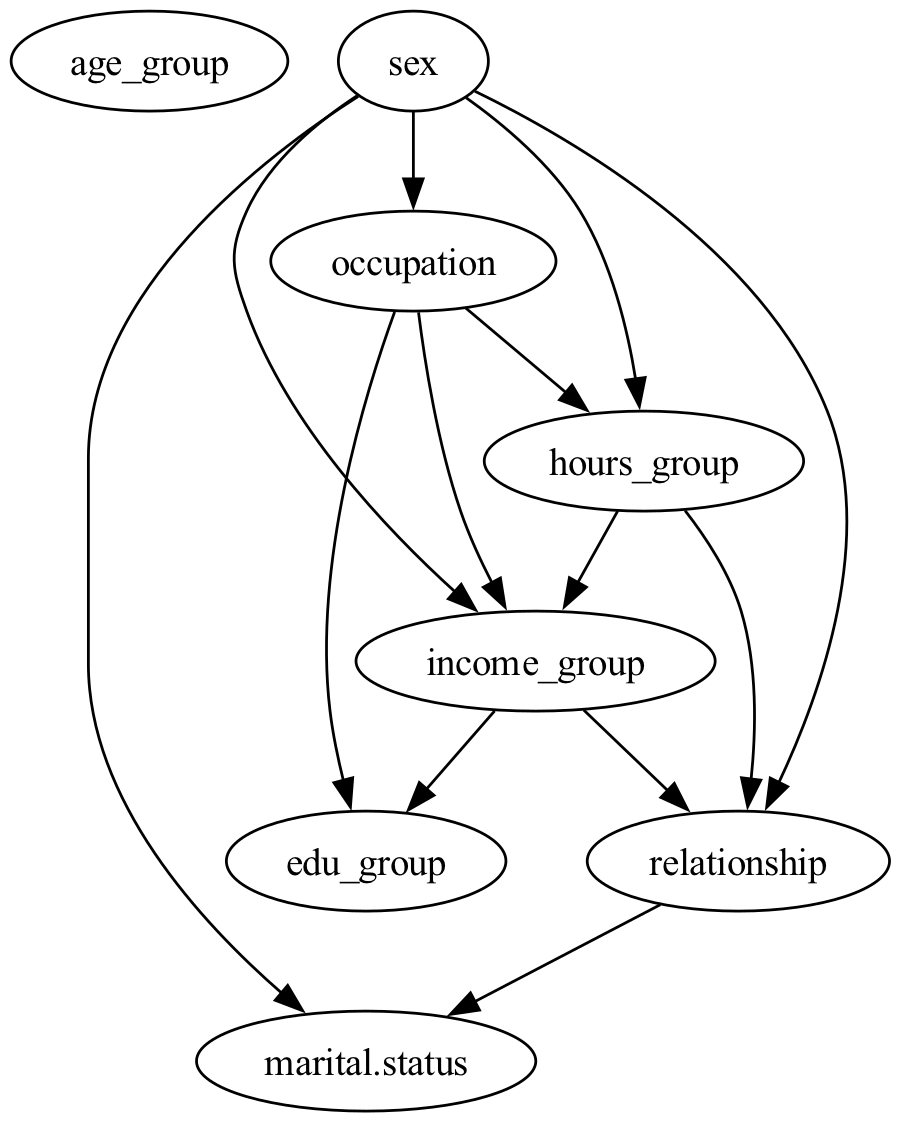

In [45]:
print("── GRaSP + BDeu + prior (CPDAG, baseline) ───────────────────────────────")
display(Image(GraphUtils.to_pydot(G_grasp_prior, labels=node_names_disc).create_png()))

print("── GRaSP + BDeu + prior + LLM penalty — CPDAG output ────────────────────")
display(Image(GraphUtils.to_pydot(G_grasp_llm, labels=node_names_disc).create_png()))

print("── GRaSP + BDeu + prior + LLM penalty — internal DAG ────────────────────")
display(Image(GraphUtils.to_pydot(G_grasp_llm_dag, labels=node_names_disc).create_png()))

In [46]:
# ── Did the LLM actually steer GRaSP toward plausible directions? ────────────
# Read every directed edge in the internal DAG and bucket by LLM penalty.
def directed_edges_with_penalty(G_dag, node_names, penalty_matrix):
    n = len(node_names)
    out = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            # GRaSP encoding for i -> j:  graph[i, j] = -1, graph[j, i] = 1
            if G_dag.graph[i, j] == -1 and G_dag.graph[j, i] == 1:
                out.append((node_names[i], node_names[j], float(penalty_matrix[i, j])))
    return out


dag_edges = directed_edges_with_penalty(G_grasp_llm_dag, node_names_disc, penalty_matrix_disc)

print("Internal-DAG edges, sorted by LLM penalty in that direction:")
for f, t, p in sorted(dag_edges, key=lambda x: x[2]):
    bucket = "plausible" if p <= 2 else ("ambiguous" if p <= 7 else "IMPLAUSIBLE")
    print(f"  {f:>16s} --> {t:<16s}   penalty = {p:4.1f}   [{bucket}]")

plausible   = sum(1 for *_, p in dag_edges if p <= 2)
ambiguous   = sum(1 for *_, p in dag_edges if 2 < p <= 7)
implausible = sum(1 for *_, p in dag_edges if p > 7)
print(f"\nScorecard: plausible={plausible}  ambiguous={ambiguous}  implausible={implausible}  "
      f"(total {len(dag_edges)} directed edges)")

# Which orientations did the LLM commit to that the CPDAG threw away?
cpdag_edges = adj_edges(G_grasp_llm, node_names_disc)
cpdag_directed   = {(f, t) for f, t, m in cpdag_edges if m == "-->"}
cpdag_undirected = {frozenset((f, t)) for f, t, m in cpdag_edges if m == "---"}

dag_only_directed = [
    (f, t, p) for f, t, p in dag_edges
    if (f, t) not in cpdag_directed and frozenset((f, t)) in cpdag_undirected
]
print(f"\nOrientations chosen by the LLM but stripped from the CPDAG ({len(dag_only_directed)}):")
for f, t, p in sorted(dag_only_directed, key=lambda x: x[2]):
    print(f"  {f} --> {t}   (LLM penalty {p:.1f})")

Internal-DAG edges, sorted by LLM penalty in that direction:
        occupation --> hours_group        penalty =  0.0   [plausible]
        occupation --> income_group       penalty =  0.0   [plausible]
      relationship --> marital.status     penalty =  0.0   [plausible]
       hours_group --> income_group       penalty =  2.0   [plausible]
               sex --> hours_group        penalty =  2.0   [plausible]
               sex --> income_group       penalty =  2.0   [plausible]
               sex --> marital.status     penalty =  2.0   [plausible]
               sex --> occupation         penalty =  2.0   [plausible]
               sex --> relationship       penalty =  2.0   [plausible]
       hours_group --> relationship       penalty =  5.0   [ambiguous]
      income_group --> relationship       penalty =  5.0   [ambiguous]
        occupation --> edu_group          penalty =  5.0   [ambiguous]
      income_group --> edu_group          penalty = 10.0   [IMPLAUSIBLE]

Scorecard: pl